### Bar Chart for Average Trip Frequency by Household Income:


In [14]:
#### Load in the data in csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

 # importing the national household travel survey
nhts_data = pd.read_csv('NHTS.csv')

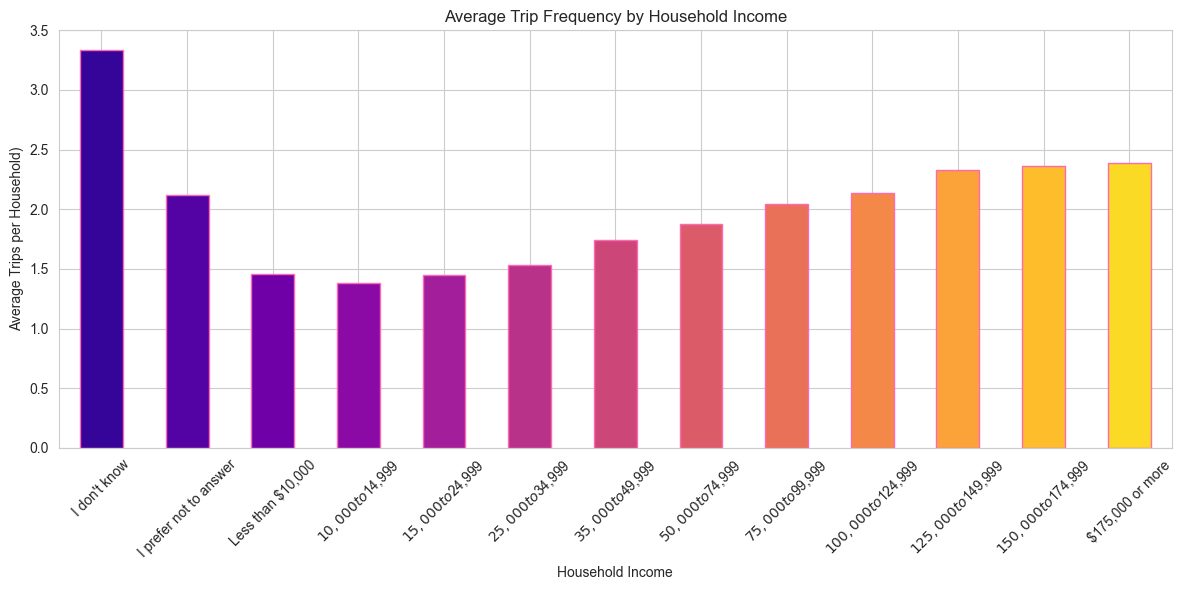

In [15]:
# This count the trips per household using travel_day
trip_freq = (nhts_data.groupby('household_id')['travel_day'].count().reset_index(name='trip_frequency'))

# This combines trip frequency with household_income
trip_freq = trip_freq.merge(nhts_data[['household_id', 'household_income']].drop_duplicates(), on='household_id',how='left')

# This calculates the average trip frequency per income category
avg_trips = (trip_freq.groupby('household_income')['trip_frequency'].mean().dropna())
income_order = [
    "I don't know",
    'I prefer not to answer',
    'Less than $10,000',
    '$10,000 to $14,999',
    '$15,000 to $24,999',
    '$25,000 to $34,999',
    '$35,000 to $49,999',
    '$50,000 to $74,999',
    '$75,000 to $99,999',
    '$100,000 to $124,999',
    '$125,000 to $149,999',
    '$150,000 to $174,999',
    '$175,000 or more'
]

avg_trips = avg_trips.reindex(income_order)

# This plots the bar graph
plt.figure(figsize=(12,6))

avg_trips.plot(kind='bar', color=sns.color_palette('plasma', len(avg_trips)), edgecolor='hotpink')

plt.xlabel('Household Income')
plt.ylabel('Average Trips per Household)')
plt.title('Average Trip Frequency by Household Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### IDM Simulation vs. Real Data:

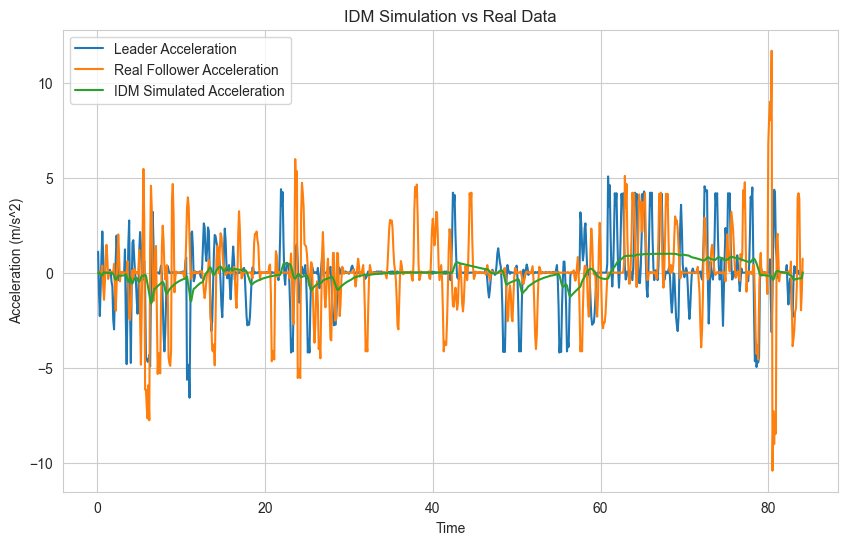

In [16]:
# Load data
df = pd.read_csv("NGSIM.csv")

# Select a trajectory
traj_id = df["trajectory_number"].iloc[0]
traj_df = df[df["trajectory_number"] == traj_id].copy()
traj_df = traj_df.sort_values("Time").reset_index(drop=True)

# Extract data
time = traj_df["Time"].values
leader_position = traj_df["leader_position(m)"].values
leader_speed = traj_df["leader_speed(m/s)"].values
leader_acc = traj_df["leader_acc(m/s^2)"].values

follower_position = traj_df["follower_position(m)"].values
follower_speed = traj_df["follower_speed(m/s)"].values
follower_acc = traj_df["follower_acc(m/s^2)"].values

dt = time[1] - time[0]
n_steps = len(time)

# IDM function
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s = max(s, 1e-6)
    s_star = s0 + v*T + (v*delta_v)/(2*np.sqrt(a*b))
    s_star = max(s_star, s0)
    return a * (1 - (v/v0)**delta - (s_star/s)**2)

# Parameters
v0 = 30
s0 = 2
T = 1.5
a_param = 1.0
b = 1.5
delta = 4

# Initialize simulation arrays
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

sim_position[0] = follower_position[0]
sim_speed[0] = follower_speed[0]

# Simulation loop
for i in range(n_steps - 1):
    s = leader_position[i] - sim_position[i]
    delta_v = sim_speed[i] - leader_speed[i]

    acc = idm_acceleration(sim_speed[i], s, delta_v, v0, s0, T, a_param, b, delta)
    sim_acc[i] = acc

    sim_speed[i+1] = sim_speed[i] + acc * dt
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

# Plot acceleration comparison
plt.figure(figsize=(10, 6))

plt.plot(time, leader_acc, label="Leader Acceleration")
plt.plot(time, follower_acc, label="Real Follower Acceleration")
plt.plot(time, sim_acc, label="IDM Simulated Acceleration")

plt.xlabel("Time")
plt.ylabel("Acceleration (m/s^2)")
plt.title("IDM Simulation vs Real Data")
plt.legend()
plt.grid(True)

plt.show()

### Histogram for Follower Speed Frequency:

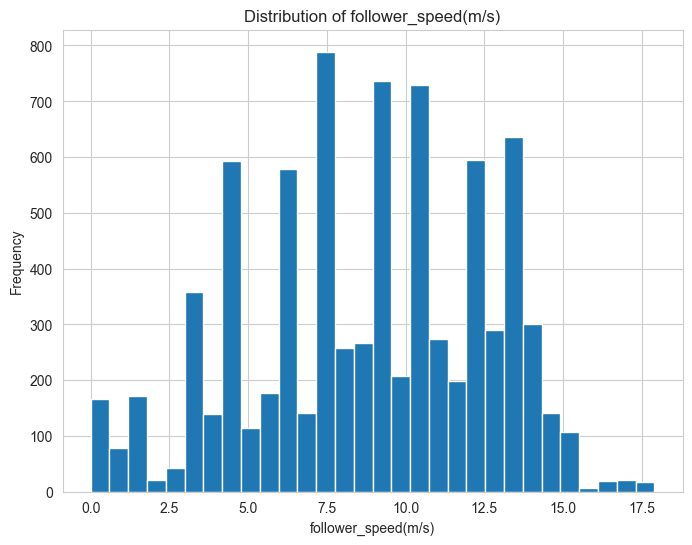

In [17]:
# Load data
df = pd.read_csv("NGSIM.csv")

# Choose variable 
variable = "follower_speed(m/s)"

# Create histogram
plt.figure(figsize=(8, 6))
plt.hist(df[variable].dropna(), bins=30)

plt.xlabel(variable)
plt.ylabel("Frequency")
plt.title(f"Distribution of {variable}")
plt.grid(True)

plt.show()

### Two Time Series Plots Analyzing Speed and Accceleration:

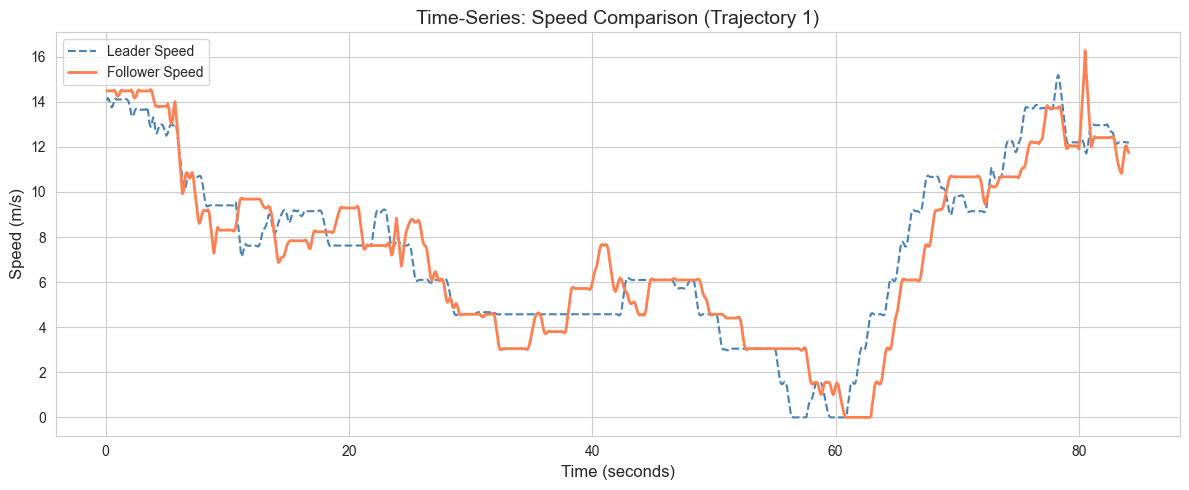

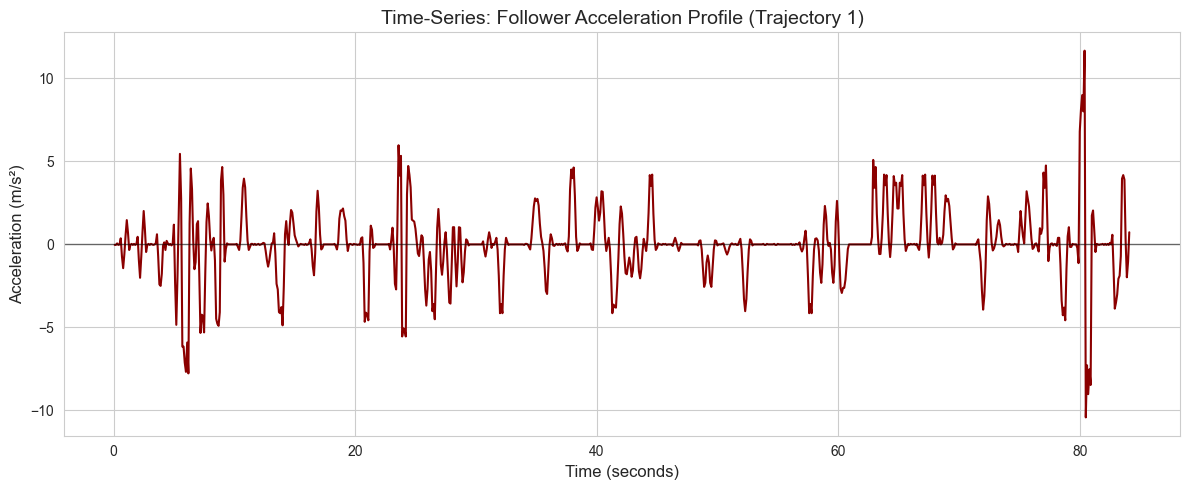

In [18]:
# Set professional style
sns.set_style('whitegrid')

# Load the NGSIM dataset
ngsim_data = pd.read_csv('NGSIM.csv')

# Select a specific vehicle pair (Trajectory 1) for detailed analysis
traj_id = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == traj_id]

# --- PLOT 1: Speed Comparison (Leader vs. Follower) ---
# This analyzes how closely the follower mirrors the leader's velocity changes.
plt.figure(figsize=(12, 5))
plt.plot(data_subset['Time'], data_subset['leader_speed(m/s)'], 
         label='Leader Speed', color='steelblue', linestyle='--')
plt.plot(data_subset['Time'], data_subset['follower_speed(m/s)'], 
         label='Follower Speed', color='coral', linewidth=2)

plt.title(f'Time-Series: Speed Comparison (Trajectory {traj_id})', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# --- PLOT 2: Follower Acceleration Profile ---
# This analyzes the smoothness or aggressiveness of the driver's behavior.
plt.figure(figsize=(12, 5))
sns.lineplot(x=data_subset['Time'], y=data_subset['follower_acc(m/s^2)'], 
             color='darkred', linewidth=1.5)

# Adding a horizontal line at 0 to distinguish acceleration from braking
plt.axhline(0, color='black', linewidth=1, alpha=0.5)

plt.title(f'Time-Series: Follower Acceleration Profile (Trajectory {traj_id})', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Acceleration (m/s²)', fontsize=12)
plt.tight_layout()
plt.show()